<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Final_project_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preprocessing & Exploration

Import libraries

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Load Data

In [3]:

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Check Imbalance

In [4]:
df['Class'].value_counts()

,count
Class,
0.0,25749
1.0,88


Handle Issues

In [5]:

df.isnull().sum()

# Delete missing values
df.dropna(inplace=True)

,0
Time,0
V1,0
V2,0
V3,1
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


Scaling

In [13]:

# Scale features
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

Visualization

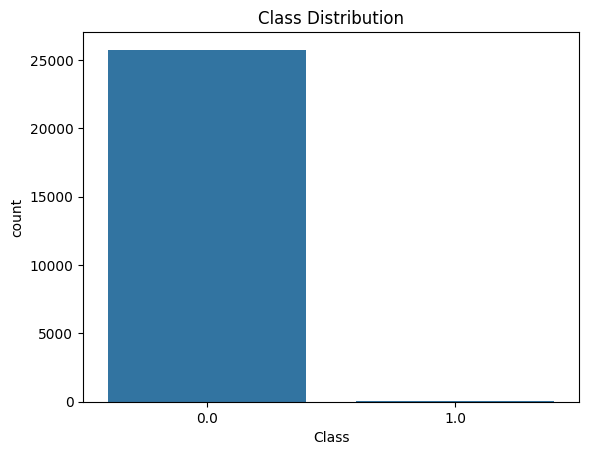

In [12]:
# Class distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

Train-Test Split

In [15]:


X = df.drop("Class", axis=1)
y = df["Class"]

# Drop rows where 'y' has NaN values to ensure stratification works correctly
# We need to drop these corresponding rows from both X and y (Gemini Correction)
non_nan_indices = y.dropna().index
X = X.loc[non_nan_indices]
y = y.loc[non_nan_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Model Selection & Development

Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(model, param_grid, scoring="f1", cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Model Evaluation

In [19]:
y_pred = best_model.predict(X_test)

Metrics

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5150
         1.0       0.88      0.83      0.86        18

    accuracy                           1.00      5168
   macro avg       0.94      0.92      0.93      5168
weighted avg       1.00      1.00      1.00      5168



Confusion Matrix

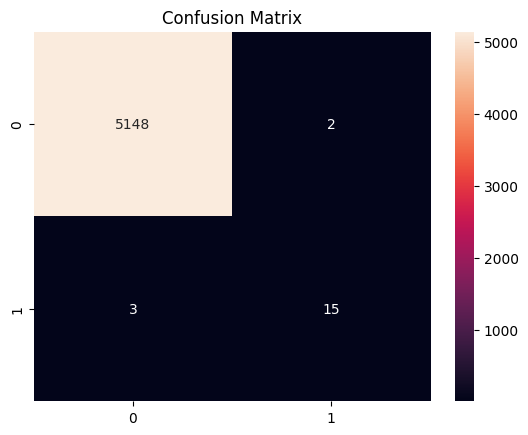

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#Model Deployment

User input interface

In [22]:
def predict_fraud(input_data):
    import numpy as np
    input_array = np.array(input_data).reshape(1, -1)
    prediction = best_model.predict(input_array)

    return "Fraud" if prediction[0] == 1 else "Not Fraud"

Use model

In [23]:
sample = X_test.iloc[0].values
print(predict_fraud(sample))

Not Fraud


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
